# Strange Attractors

We again consider the Hénon map
$$\begin{align}X_{n+1} &= 1-aX_n^2+bY_n \\
Y_{n+1} &= X_n,\end{align}$$
with $a = 1.4$ and $b=0.3$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

In [2]:
def henon_map(x, y, a=1.4, b=0.3):
    x_new = 1 - (a * x**2) + (b * y)
    y_new = x
    return x_new, y_new

def henon_series(x0, y0, n, a=1.4, b=0.3):
    xs = [x0]
    ys = [y0]
    for _ in range(n):
        x_new, y_new = henon_map(xs[-1], ys[-1], a, b)
        xs.append(x_new)
        ys.append(y_new)
    return xs, ys

def henon_map_iterations(x0, y0, n_total, n_skip, a=1.4, b=0.3):
    xs, ys = henon_series(x0, y0, n_total, a=a, b=b)
    return xs[n_skip:], ys[n_skip:]

### Testing deviation in initial conditions and solutions

We can see from a long-run of the map below (3000 iterations), that the trajectory appears to be bounded within a finite interval, does not seem to have any obvious repeating cycle, but has some weak structure in terms of the sequence of values it takes (by looking at the bottom whitespace along the y-axis), and it looks noisy — all of which are suggestive of a chaotic attractor, but visual inspection alone cannot be treated as conclusive evidence.

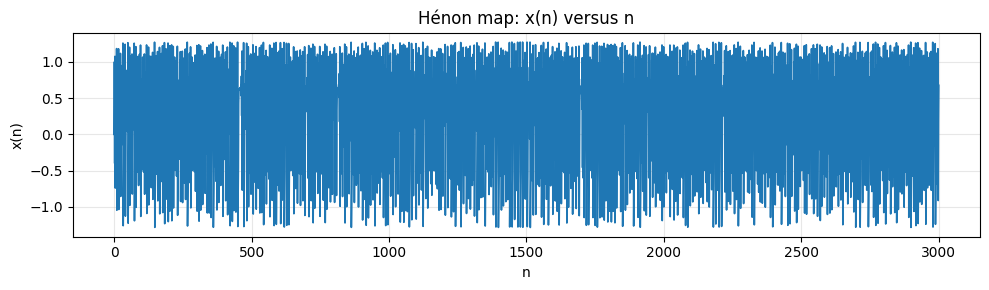

In [3]:
x0, y0 = 0.0, 0.0 # in the basin of attraction
n_total = 3000
xs, ys = henon_series(x0, y0, n_total)
xs = np.asarray(xs)
ys = np.asarray(ys)

plt.figure(figsize=(10, 3))
plt.plot(np.arange(len(xs)), xs, lw=1.2)
plt.xlabel('n')
plt.ylabel('x(n)')
plt.title('Hénon map: x(n) versus n')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Therefore, we can choose different but nearby initial conditions and analyze the rate of deviation to better test for chaos.

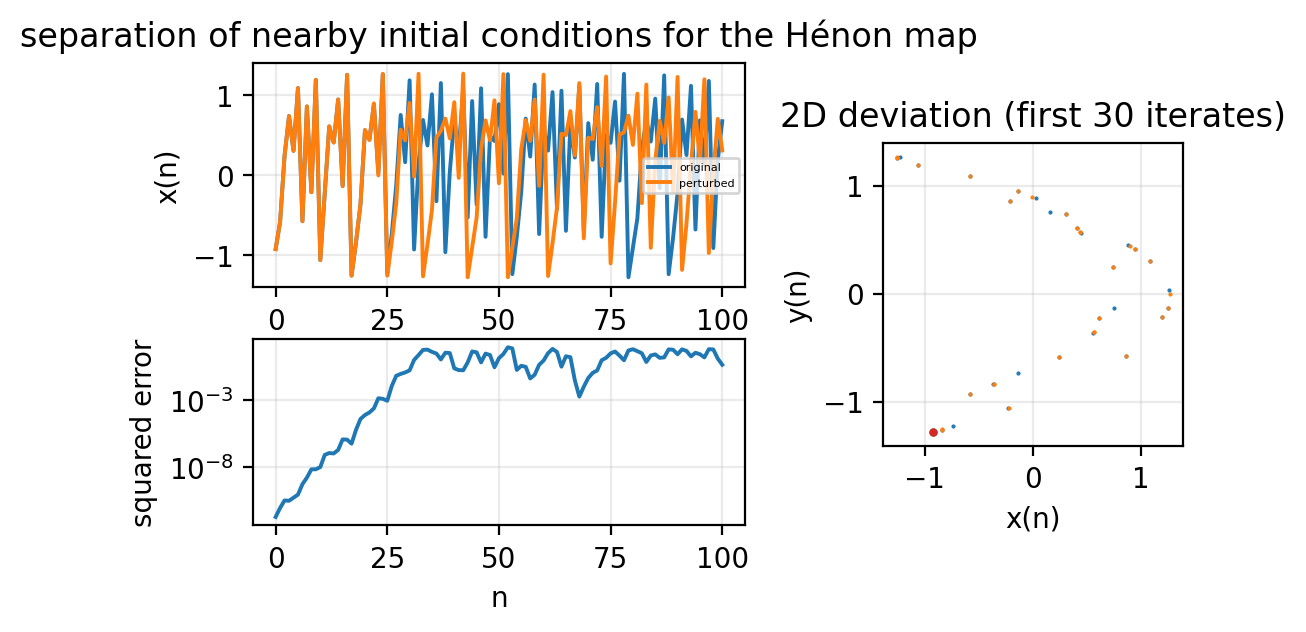

In [4]:
n0 = 2900
ns = np.arange(xs[n0:].size)
n_plot = 30
ns_plot = ns[:n_plot]
eps = 1e-6
x0p, y0p = xs[n0] + eps, ys[n0] + eps
xs_ptb, ys_ptb = henon_series(x0p, y0p, ns.size-1)
xs_ptb = np.asarray(xs_ptb)
ys_ptb = np.asarray(ys_ptb)
sq_err = (xs_ptb - xs[n0:]) ** 2 + (ys_ptb - ys[n0:]) ** 2

# plot
fig = plt.figure(figsize=(6, 3), dpi=200)
gs = GridSpec(2, 2, width_ratios=[1.8, 1.1], height_ratios=[1.2, 1.0], hspace=0.25, wspace=0.35)
ax_x   = fig.add_subplot(gs[0, 0])
ax_err = fig.add_subplot(gs[1, 0], sharex=ax_x)
ax_2d  = fig.add_subplot(gs[:, 1])
ax_x.plot(ns, xs[n0:], lw=1.4, label='original')
ax_x.plot(ns, xs_ptb, lw=1.4, label='perturbed')
ax_x.set_ylabel('x(n)')
ax_x.set_title('separation of nearby initial conditions for the Hénon map')
ax_x.legend(loc='center right', fontsize=4, framealpha=0.8)
ax_x.grid(alpha=0.25)
ax_err.semilogy(ns, sq_err, lw=1.4)
ax_err.set_xlabel('n')
ax_err.set_ylabel('squared error')
ax_err.grid(alpha=0.25)
ax_2d.plot(xs[n0:n0+n_plot], ys[n0:n0+n_plot], '.', markersize=1, label='original')
ax_2d.plot(xs_ptb[:n_plot], ys_ptb[:n_plot], '.', markersize=1, label='perturbed')
ax_2d.plot(xs[n0], ys[n0], 'o', ms=2)
ax_2d.plot(xs_ptb[0], ys_ptb[0], 'o', ms=2)
ax_2d.set_xlabel('x(n)')
ax_2d.set_ylabel('y(n)')
ax_2d.set_title(f'2D deviation (first {n_plot} iterates)')
ax_2d.set_aspect('equal', adjustable='box')
ax_2d.grid(alpha=0.25)
plt.show()

### Visualizing the attractor
We compute $10^5$ steps and skip first $2000$ to try and ensure that we plot points on or very close to the attractor set.

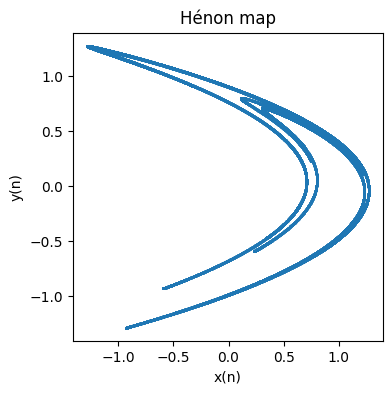

In [10]:
xs, ys = henon_map_iterations(0, 0, 100000, 2000)
xs = np.asarray(xs)
ys = np.asarray(ys)

plt.figure(figsize=(4, 4))
plt.plot(xs, ys, '.', markersize=1)
plt.xlabel('x(n)')
plt.ylabel('y(n)')
plt.axis('equal')
plt.title('Hénon map')
plt.show()

### Zooming in to see finer structure
We zoom into a section of the mapped points above to see that they essentially comprise sets of lines of sets of lines and so on (suggestively).

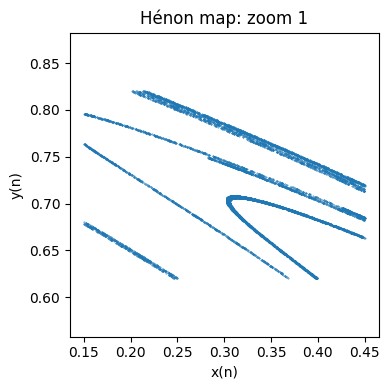

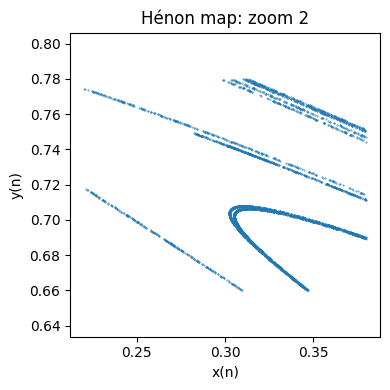

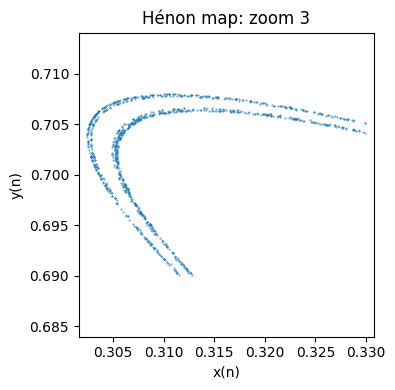

In [13]:
zoom_windows = [
    (0.15, 0.45, 0.62, 0.82),
    (0.22, 0.38, 0.66, 0.78),
    (0.29, 0.33, 0.69, 0.71),
]

for i, (xmin, xmax, ymin, ymax) in enumerate(zoom_windows, start=1):
    mask = (
        (xs >= xmin) & (xs <= xmax) &
        (ys >= ymin) & (ys <= ymax)
    )
    plt.figure(figsize=(4, 4))
    plt.plot(xs[mask], ys[mask], '.', markersize=0.7)
    plt.xlim(xmin, xmax)
    plt.ylim(ymin, ymax)
    plt.axis('equal')
    plt.xlabel('x(n)')
    plt.ylabel('y(n)')
    plt.title(f'Hénon map: zoom {i}')
    plt.tight_layout()
    plt.show()

### Basin of attraction
We simply do repeated iterations of the Hénon map over a meshgrid to approximate its basin of attraction. The grey region converges onto the map, while the white region escapes it.

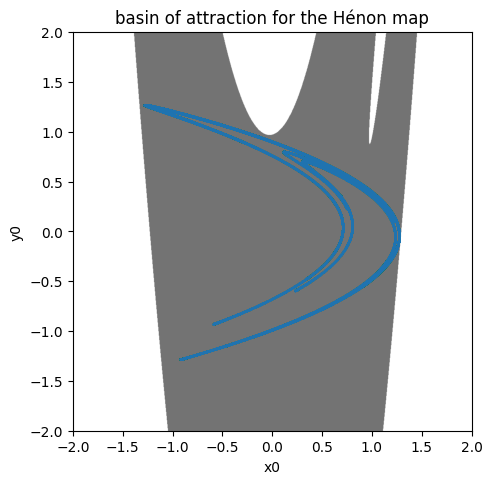

In [17]:
def henon_basin(xmin, xmax, ymin, ymax, n_grid, n_iters, a=1.4, b=0.3, overflow=1e2):
    x = np.linspace(xmin, xmax, n_grid)
    y = np.linspace(ymin, ymax, n_grid)
    X0, Y0 = np.meshgrid(x, y)

    X = X0.copy()
    Y = Y0.copy()
    in_basin = np.ones_like(X, dtype=bool)
    for _ in range(n_iters):
        X_new = np.zeros_like(X)
        Y_new = np.zeros_like(Y)
        X_new[in_basin] = 1 - a * X[in_basin]**2 + b * Y[in_basin]
        Y_new[in_basin] = X[in_basin]
        escaped = (
            in_basin &
            (
                ~np.isfinite(X_new) |
                ~np.isfinite(Y_new) |
                (np.abs(X_new) > overflow) |
                (np.abs(Y_new) > overflow)
            )
        )
        in_basin[escaped] = False
        X, Y = X_new, Y_new
    return X0, Y0, in_basin

xmin, xmax = -2.0, 2.0
ymin, ymax = -2.0, 2.0
X0, Y0, basin = henon_basin(
    xmin, xmax, ymin, ymax,
    n_grid=1000,
    n_iters=500
)

# overlay of the attractor
xs_attr, ys_attr = henon_map_iterations(0.0, 0.0, 100000, 1000)

plt.figure(figsize=(5, 5))
plt.imshow(
    basin.astype(float),
    extent=[xmin, xmax, ymin, ymax],
    origin='lower',
    cmap='Greys',
    alpha=0.55
)
plt.plot(xs_attr, ys_attr, '.', markersize=0.3)
plt.xlabel('x0')
plt.ylabel('y0')
plt.title('basin of attraction for the Hénon map')
plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)
plt.tight_layout()
plt.show()